<a href="https://colab.research.google.com/github/vincent-chen09/MG-Gravitational-waves/blob/main/GW230529_Parameter_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install gwpy
%pip install lalsuite
%pip install bilby

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 60.3 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 45.0.6 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 45.0.6 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.core.prior import Uniform
from gwpy.timeseries import TimeSeries
from gwpy.signal import filter_design
from gwosc import datasets
logger = bilby.core.utils.logger
outdir = "/content/drive/My Drive/Results_GW230529/"


ldata = TimeSeries.fetch_open_data('L1', 1369419316 , 1369419320  )
label = "GW230529"


L1 = bilby.gw.detector.get_empty_interferometer("L1")

/usr/local/lib/python3.12/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


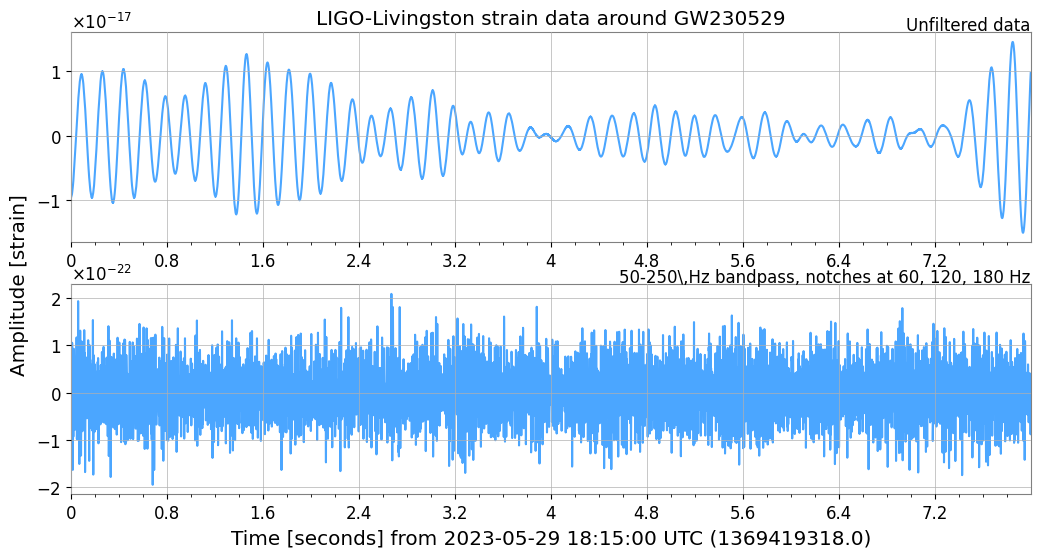

In [ ]:
event_start_time = 1369419318      # event GPS time at which GW was discovered
post_event = 9                  # time after event
pre_event = 1                 # time before event
duration = pre_event + post_event  # total time range containing event
analysis_begin = event_start_time - pre_event

L1_data = TimeSeries.fetch_open_data("L1", analysis_begin,
                                     analysis_begin + duration,
                                     sample_rate=4096, cache=True)
bp = filter_design.bandpass(50, 250, L1_data.sample_rate)
notches = [filter_design.notch(line, L1_data.sample_rate) for
           line in (9, 13.8, 33.7, 34.7, 35.3, 60, 120, 180,300, 331.3, 500,600, 900, 1000,1083.1, 1500)]
zpk = filter_design.concatenate_zpks(bp, *notches)
lfilt = L1_data.filter(zpk, filtfilt=True)
ldata = L1_data.crop(*L1_data.span.contract(1))
lfilt = lfilt.crop(*lfilt.span.contract(1))
from gwpy.plot import Plot
plot = Plot(ldata, lfilt, figsize=[12, 6], separate=True, sharex=True,
            color='gwpy:ligo-livingston')
ax1, ax2 = plot.axes
ax1.set_title('LIGO-Livingston strain data around GW230529')
ax1.text(1.0, 1.01, 'Unfiltered data', transform=ax1.transAxes, ha='right')
ax1.set_ylabel('Amplitude [strain]', y=-0.2)
ax2.set_ylabel('')
ax2.text(1.0, 1.01, r'50-250\,Hz bandpass, notches at 60, 120, 180 Hz',
         transform=ax2.transAxes, ha='right')
plot.show()


In [ ]:

L1.set_strain_data_from_gwpy_timeseries(L1_data)

In [ ]:
# duration typically multiplied by 32 for psd
psd_duration = duration * 32
psd_begin = analysis_begin - psd_duration

# fetch data for psd

L1psd = TimeSeries.fetch_open_data(
    "L1", psd_begin, psd_begin + psd_duration,
    sample_rate=4096, cache=True)

# set interferometers with psd data
psd_alpha = 2 * L1.strain_data.roll_off / duration

L1psd_data = L1psd.psd(fftlength=duration, overlap=0, window=("tukey", psd_alpha), method="median")

L1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=L1psd_data.frequencies.value, psd_array=L1psd_data.value)

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3045105701.py:12: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Strain [strain/$\sqrt{Hz}$]")


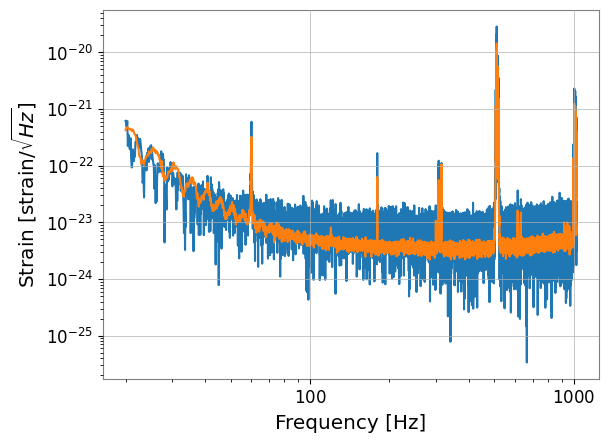

In [ ]:

L1.maximum_frequency = 1024

plt.figure()
idxs = L1.strain_data.frequency_mask
a,b = list(L1.strain_data.frequency_array[idxs]),list(np.abs(L1.strain_data.frequency_domain_strain[idxs]))
c,d = list(L1.power_spectral_density.frequency_array[idxs]),list(L1.power_spectral_density.asd_array[idxs])
plt.plot(a,b)
plt.plot(c,d)
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.savefig("strainvfreq")


In [ ]:
prior = bilby.core.prior.PriorDict()
# uniform priors for variable parameters
prior['chirp_mass'] = Uniform(name='chirp_mass', minimum=1.0,maximum=10.0)
#prior['mass_ratio'] = Uniform(name='mass_ratio', minimum=0.3, maximum=1)
#prior['phase'] = Uniform(name="phase", minimum=0, maximum=2*np.pi)
#prior['geocent_time'] = Uniform(name="geocent_time", minimum=event_start_time-2,
                                #maximum=event_start_time+2)
#prior['dec'] =  Uniform(name='dec', minimum=-np.pi,maximum=np.pi) #declination
#prior['ra'] =  Uniform(name='ra', minimum=0,maximum=2*np.pi)  #right ascension
#prior['theta_jn'] =  0 #angles between line of sight and plane
#prior['psi'] =  Uniform(name='psi', minimum=0,maximum=2*np.pi) #polarization angle of wave
#prior['luminosity_distance'] = Uniform(name="luminosity_distance", minimum =200, maximum = 600)
# fixed values for all other parameters
prior['a_1'] =  Uniform(name='a_1', minimum=0.01,maximum=0.99)
prior['a_2'] =  Uniform(name='a_2', minimum=0.01,maximum=0.99)

prior['tilt_1'] =  0.0
prior['tilt_2'] =  0.0
prior['phi_12'] =  0.0
prior['phi_jl'] =  0.0

prior['dec'] =  -0.3 #declination
prior['ra'] =  3.28  #right ascension
prior['theta_jn'] =  0.5 #angles between line of sight and plane
prior['psi'] =  0.785 #polarization angle of wave
prior['mass_ratio'] = 0.39
prior['phase'] = 3.16
prior['luminosity_distance'] = 201
#prior['chirp_mass'] = 1.94
prior['geocent_time'] = 1369419318
interferometers = [L1]

waveform_arguments = dict(waveform_approximant='IMRPhenomPv2', reference_frequency=50., minimum_frequency=20.)

# set sampling frequency of data
sampling_frequency = 2048.

# generate waveforms
waveform_generator = bilby.gw.WaveformGenerator(duration=duration, sampling_frequency=sampling_frequency,frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,waveform_arguments=waveform_arguments)

likelihood = bilby.gw.GravitationalWaveTransient(interferometers=interferometers, waveform_generator=waveform_generator)

05:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


In [ ]:
nlive = 1000          # live points
stop = 0.1            # stopping criterion(change in log of posterior probability)
method = "unif"       # method of sampling
sampler = "dynesty"   # sampler to use

result = bilby.run_sampler(
    likelihood, prior, sampler=sampler, outdir=outdir, label=label,
    conversion_function=bilby.gw.conversion.generate_all_bbh_parameters,
    sample=method, nlive=nlive, dlogz=stop)

result.plot_corner()

05:25 bilby INFO    : Running for label 'GW230529', output will be saved to '/content/drive/My Drive/Results_GW230529/'
05:25 bilby INFO    : Using lal version 7.7.0
05:25 bilby INFO    : Using lal git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: UNCLEAN: Modified working tree
05:25 bilby INFO    : Using lalsimulation version 6.2.0
05:25 bilby INFO    : Using lalsimulation git version Branch: None;Tag: lalsuite-v7.26.1;Id: c90e1175f5e238741185744a4e516e58d42a9aec;;Builder: Unknown User <>;Repository status: UNCLEAN: Modified working tree
05:25 bilby INFO    : Analysis priors:
05:25 bilby INFO    : chirp_mass=Uniform(minimum=1.0, maximum=10.0, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
05:25 bilby INFO    : a_1=Uniform(minimum=0.01, maximum=0.99, name='a_1', latex_label='$a_1$', unit=None, boundary=None)
05:25 bilby INFO    : a_2=Uniform(minimum=0.01, maximum=0.99, nam

10180it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
05:33 bilby INFO    : Written checkpoint file /content/drive/My Drive/Results_GW230529//GW230529_resume.pickle
/usr/local/lib/python3.12/dist-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable boot

Exception while calling loglikelihood function:
  params: [1.69764674 0.64432714 0.16935873]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/dynesty/dynesty.py", line 913, in __call__
    return self.func(np.asarray(x).copy(), *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/bilby/core/sampler/dynesty.py", line 54, in _log_likelihood_wrapper
    return _sampling_convenience_dump.likelihood.log_likelihood_ratio()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/bilby/gw/likelihood/base.py", line 408, in log_likelihood_ratio
    self.waveform_generator.frequency_domain_strain(self.parameters)
  File "/usr/local/lib/python3.12/dist-packages/bilby/gw/waveform_generator.py", line 131, in frequency_domain_strain
    return self._calculate_strain(model=self.frequency_domain_source_model,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/

SystemExit: 130

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
posts = result.posterior
#posts = pd.read_csv("/content/drive/My Drive/Results/GW150914_result.json", sep = " ")

chirp_mass_samps = list(posts["chirp_mass"])
mass_ratio_samps = list(posts["mass_ratio"])
geocent_time_samps = list(posts["geocent_time"])

chirp_mass, chirp_mass_err = np.mean(chirp_mass_samps), np.std(chirp_mass_samps)
mass_ratio, mass_ratio_err = np.mean(mass_ratio_samps), np.std(mass_ratio_samps)
geocent_time, geocent_time_err = np.mean(geocent_time_samps), np.std(geocent_time_samps)

print("Parameters describing the GW150914 signal: \n \n" +
      "  chirp mass = {}   \u00B1 {} \n".format(chirp_mass, chirp_mass_err) +
      "  mass ratio = {} \u00B1 {} \n \n".format(mass_ratio, mass_ratio_err) +
      "geocent time = {} \u00B1 {} \n".format(geocent_time, geocent_time_err) +
      "True geocent time = 1126259462.4")

In [ ]:
def bbhMass(chirp,chirperr,ratio,ratioerr):
    """
    Function that calculates black hole masses with errors

    m1,m2 = larger black hole mass, smaller black hole mass
    chirp = (m1*m2)**(3/5) / (m1+m2)**(1/5)
    ratio = m2/m1
    """

    # use chirp mass and ratio to find primary black hole mass
    m1 = chirp / (ratio**(3/5) * (1/(1+ratio))**(1/5))
    m1err = (chirp + chirperr) / ((ratio-ratioerr)**(3/5) *
                                  (1/(1+(ratio+ratioerr))**(1/5))) - m1

    # use primary black hole mass and ratio to find secondary black hole mass
    m2 = m1*ratio
    m2err = (m1+m1err)*(ratio+ratioerr) - m2

    return (m1,m1err),(m2,m2err)

(m1,m1err), (m2,m2err) = bbhMass(chirp_mass,chirp_mass_err,
                                 mass_ratio,mass_ratio_err)

print("Black hole masses from sampling (in solar masses): \n \n" +
      "   largest black hole = {} \u00B1 {} \n".format(m1, m1err) +
      "  smallest black hole = {} \u00B1 {} \n \n".format(m2, m2err) +
      "Accepted black hole masses (in solar masses): \n \n" +
      "   largest black hole = {}\n".format(36.2) +
      "  smallest black hole = {}".format(29.1))